In [1]:
import numpy as np
import pandas as pd
import pickle, os
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Embedding, GRU,
Dense, Dropout)
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score,
precision_score, recall_score, f1_score,
confusion_matrix, classification_report,
roc_auc_score, roc_curve)
print("Libraries imported!")

Libraries imported!


In [2]:
df = pd.read_csv('cleaned_data.csv')
MAX_WORDS = 10000
MAX_LEN = 300
tokenizer = Tokenizer(num_words=MAX_WORDS,
oov_token='<OOV>')
tokenizer.fit_on_texts(df['clean_text'].astype(str))
sequences = tokenizer.texts_to_sequences(
df['clean_text'].astype(str))
X_pad = pad_sequences(sequences,
maxlen=MAX_LEN, truncating='post')
X_train, X_test, y_train, y_test = train_test_split(
X_pad, df['label'].values,
test_size=0.2, random_state=42,
stratify=df['label'])
print(f"Train: {X_train.shape}")
print(f"Test : {X_test.shape}")
print(f"Vocab size: {len(tokenizer.word_index):,}")

Train: (35378, 300)
Test : (8845, 300)
Vocab size: 203,178


In [3]:
model = Sequential([
Embedding(MAX_WORDS, 64, input_length=MAX_LEN),
GRU(64, return_sequences=True),
Dropout(0.3),
GRU(32),
Dropout(0.3),
Dense(1, activation='sigmoid')
])
model.compile(
optimizer='adam',
loss='binary_crossentropy',
metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [4]:
es = EarlyStopping(
monitor='val_loss',
patience=3,
restore_best_weights=True)
history = model.fit(
X_train, y_train,
epochs=10,
batch_size=64,
validation_split=0.1,
callbacks=[es],
verbose=1)
print("GRU training complete!")

Epoch 1/10
498/498 ━━━━━━━━━━━━━━━━━━━━ 160s 310ms/step - accuracy: 0.9490 - loss: 0.1493 - val_accuracy: 0.9912 - val_loss: 0.0417
Epoch 2/10
498/498 ━━━━━━━━━━━━━━━━━━━━ 199s 303ms/step - accuracy: 0.9884 - loss: 0.0459 - val_accuracy: 0.9893 - val_loss: 0.0430
Epoch 3/10
498/498 ━━━━━━━━━━━━━━━━━━━━ 204s 307ms/step - accuracy: 0.9930 - loss: 0.0268 - val_accuracy: 0.9952 - val_loss: 0.0152
Epoch 4/10
498/498 ━━━━━━━━━━━━━━━━━━━━ 254s 510ms/step - accuracy: 0.9976 - loss: 0.0103 - val_accuracy: 0.9949 - val_loss: 0.0199
Epoch 5/10
498/498 ━━━━━━━━━━━━━━━━━━━━ 176s 354ms/step - accuracy: 0.9991 - loss: 0.0040 - val_accuracy: 0.9941 - val_loss: 0.0217
Epoch 6/10
498/498 ━━━━━━━━━━━━━━━━━━━━ 161s 323ms/step - accuracy: 0.9994 - loss: 0.0031 - val_accuracy: 0.9969 - val_loss: 0.0108
Epoch 7/10
498/498 ━━━━━━━━━━━━━━━━━━━━ 202s 323ms/step - accuracy: 0.9993 - loss: 0.0030 - val_accuracy: 0.9980 - val_loss: 0.0094
Epoch 8/10
498/498 ━━━━━━━━━━━━━━━━━━━━ 161s 323ms/step - accuracy: 0.9997 -

In [5]:
y_prob = model.predict(X_test).flatten()
y_pred = (y_prob >= 0.5).astype(int)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
print("=" * 50)
print(" GRU — EVALUATION RESULTS")
print("=" * 50)
print(f" Accuracy : {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f" Precision : {precision:.4f}")
print(f" Recall : {recall:.4f}")
print(f" F1-Score : {f1:.4f}")
print(f" ROC-AUC : {roc_auc:.4f}")
print("=" * 50)
print(classification_report(y_test, y_pred,
target_names=['Fake','Real']))

277/277 ━━━━━━━━━━━━━━━━━━━━ 24s 83ms/step
 GRU — EVALUATION RESULTS
 Accuracy : 0.9967 (99.67%)
 Precision : 0.9951
 Recall : 0.9981
 F1-Score : 0.9966
 ROC-AUC : 0.9995
              precision    recall  f1-score   support

        Fake       1.00      1.00      1.00      4562
        Real       1.00      1.00      1.00      4283

    accuracy                           1.00      8845
   macro avg       1.00      1.00      1.00      8845
weighted avg       1.00      1.00      1.00      8845



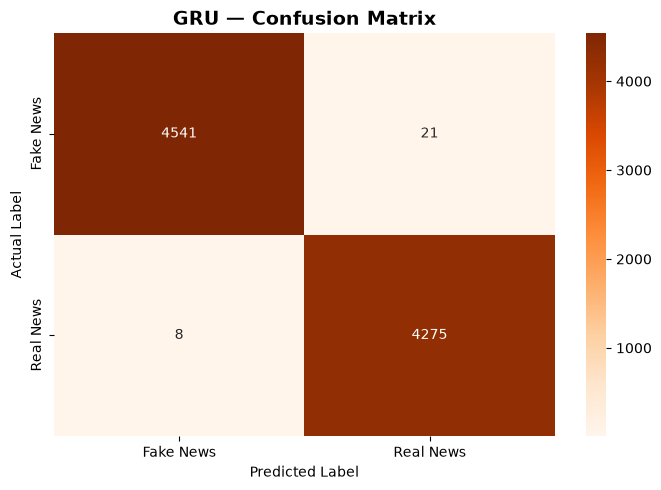

In [6]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d',
cmap='Oranges',
xticklabels=['Fake News','Real News'],
yticklabels=['Fake News','Real News'])
plt.title('GRU — Confusion Matrix',
fontsize=14, fontweight='bold')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('gru_confusion_matrix.png', dpi=150)
plt.show()


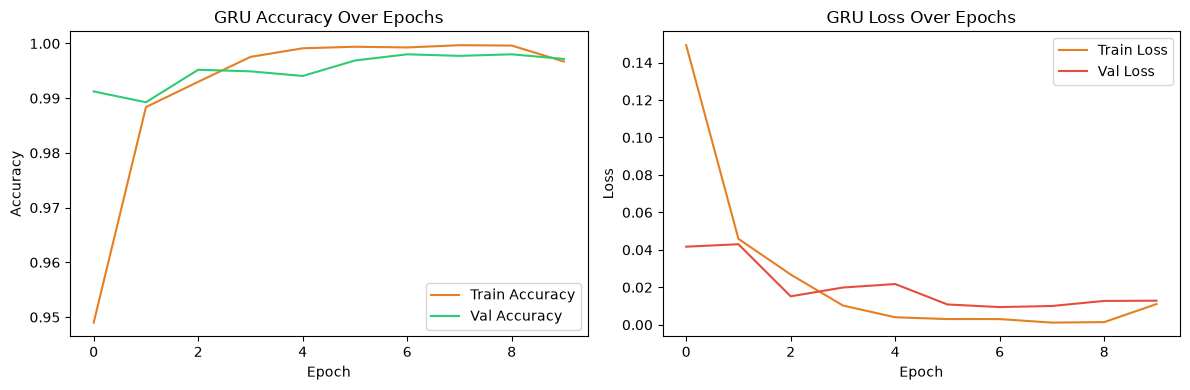

Training history chart saved!


In [7]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'],
label='Train Accuracy', color='#e67e22')
plt.plot(history.history['val_accuracy'],
label='Val Accuracy', color='#2ecc71')
plt.title('GRU Accuracy Over Epochs')
plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'],
label='Train Loss', color='#e67e22')
plt.plot(history.history['val_loss'],
label='Val Loss', color='#e74c3c')
plt.title('GRU Loss Over Epochs')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.savefig('gru_training_history.png', dpi=150)
plt.show()
print("Training history chart saved!")

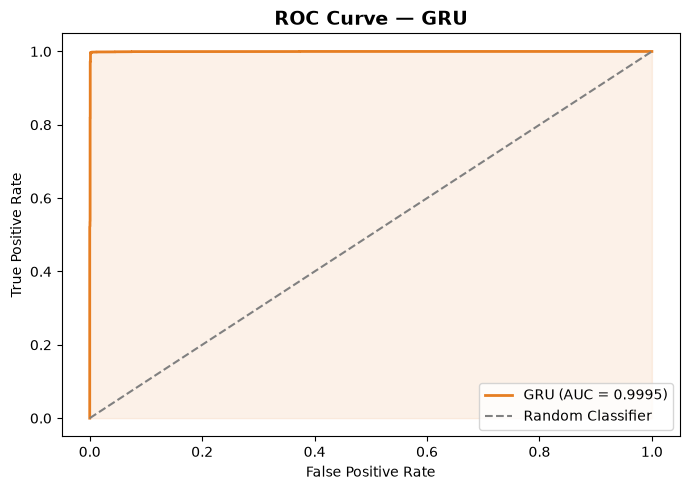

ROC Curve saved!


In [8]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='#e67e22', linewidth=2,
label=f'GRU (AUC = {roc_auc:.4f})')
plt.plot([0,1],[0,1], color='gray',
linestyle='--', label='Random Classifier')
plt.fill_between(fpr, tpr, alpha=0.1, color='#e67e22')
plt.title('ROC Curve — GRU',
fontsize=14, fontweight='bold')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('gru_roc_curve.png', dpi=150)
plt.show()
print("ROC Curve saved!")

In [10]:
os.makedirs('saved_models', exist_ok=True)
model.save('saved_models/gru_model.h5')
pickle.dump(tokenizer, open('saved_models/gru_tokenizer.pkl', 'wb'))

print("GRU model and tokenizer saved!")
print("\nFiles in saved_models/:")

# Indented block inside loop:
for f in os.listdir('saved_models'):
    print(f"  {f}")

GRU model and tokenizer saved!

Files in saved_models/:
  gru_model.h5
  gru_tokenizer.pkl
  rf_model.pkl
  word2vec.model
  word2vec.model.syn1neg.npy
  word2vec.model.wv.vectors.npy
  X_test_w2v.npy
  X_train_w2v.npy
  y_test.npy
  y_train.npy


In [11]:
print("=" * 55)
print(" DL MODEL SUMMARY — GRU (Eshan)")
print("=" * 55)
print(f"""
Architecture : GRU (Gated Recurrent Unit)
Embedding Dim : 64
GRU Layer 1 : 64 units
GRU Layer 2 : 32 units
Dropout : 0.3
Max Words : {MAX_WORDS:,}
Max Length : {MAX_LEN}
Accuracy : {accuracy*100:.2f}%
Precision : {precision:.4f}
Recall : {recall:.4f}
F1-Score : {f1:.4f}
ROC-AUC : {roc_auc:.4f}
Saved Files:
gru_model.h5
gru_tokenizer.pkl
gru_confusion_matrix.png
gru_training_history.png
gru_roc_curve.png
""")


 DL MODEL SUMMARY — GRU (Eshan)

Architecture : GRU (Gated Recurrent Unit)
Embedding Dim : 64
GRU Layer 1 : 64 units
GRU Layer 2 : 32 units
Dropout : 0.3
Max Words : 10,000
Max Length : 300
Accuracy : 99.67%
Precision : 0.9951
Recall : 0.9981
F1-Score : 0.9966
ROC-AUC : 0.9995
Saved Files:
gru_model.h5
gru_tokenizer.pkl
gru_confusion_matrix.png
gru_training_history.png
gru_roc_curve.png

